#Regression

* Predicting a numerical variable based on other combination of variables.

In [1]:
import tensorflow as tf
print(tf.__version__)

2.19.0


#creating data to view

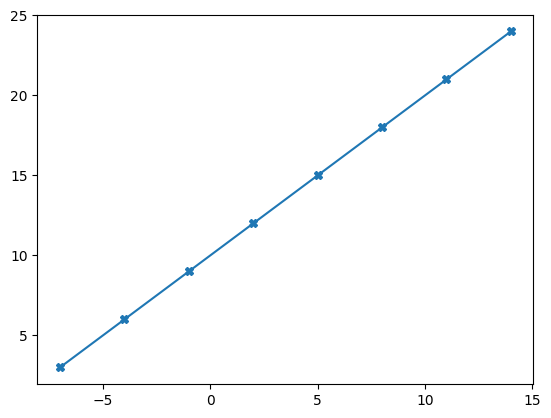

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#features(independent variable)
x = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])

#labels (dependent variable)
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

#plotting
plt.plot(x,y, "X-")
plt.show(block=True)

In [3]:
# relationship y = x + 10
assert np.all(y == x + 10)

# Input and Output Shapes

In [4]:
house_info = tf.constant(["bedroom", "bathroom", "garage"])
house_price = tf.constant([939700])
house_info, house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700], dtype=int32)>)

In [5]:
x = tf.constant(x)
y = tf.constant(y)

# modelling

* **Creating a model** - define th i/o layers, as well as the hidden layes of a deep learning model.
* **Compiling a model** - define the loss function (How wrong the model is) & optimizer (improve the learning) & evaluation metrics
* **fitting the model** - finding patterns


In [6]:
tf.random.set_seed(42)
#using sequential API
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

#compiling
model.compile(loss=tf.keras.losses.mae, ## mae => np.mean(np.abs(y_true - y_pred))
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"]) #SGD => stochastic gradient descent
##removig layer => model.pop()
# model fitting

# Reshaping x to have an extra dimension
x_reshaped = tf.expand_dims(x, axis=-1)

model.fit(x_reshaped, y, epochs=5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 20.8419 - mae: 20.8419
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 20.4753 - mae: 20.4753
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - loss: 20.1941 - mae: 20.1941
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 19.9128 - mae: 19.9128
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 19.6316 - mae: 19.6316


In [7]:
y_pred = model.predict(tf.constant([17, 0]))
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


array([[-21.422556],
       [  0.035   ]], dtype=float32)

#Improving the model

In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="sigmoid"),
    tf.keras.layers.Dense(100, activation="sigmoid"),
    tf.keras.layers.Dense(1) # Changed to 1 unit to match the label shape
])

## tf.keras.optimizers.RMSprp(learning_rate=0.001, rho-0.9)
#=>step size
#=> discounting factor controling the influence of past gradent and the current gradient

model.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=["mae"]
)
model.fit(x_reshaped, y, epochs=5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 681ms/step - loss: 14.1892 - mae: 14.1892
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 13.8819 - mae: 13.8819
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 13.5750 - mae: 13.5750
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 13.2684 - mae: 13.2684
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 12.9619 - mae: 12.9619


In [9]:
model.predict(tf.constant([12.0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


array([[0.85237956]], dtype=float32)

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(500, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1)
])

model.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001,
    ),
    metrics=["mae"]
)
model.fit(x_reshaped, y, epochs=100)

In [60]:
model.predict(tf.constant([11.0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


array([[20.842865]], dtype=float32)

In [48]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(500, activation="relu"),
    tf.keras.layers.Dense(200, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1)
])
model.compile(
    loss=tf.losses.mae, ## / tf["mae"]
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), ## lr -(vital hyperparam)
    metrics=["mae"]
)
model.fit(x_reshaped, y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 13.5803 - mae: 13.5803
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 9.3989 - mae: 9.3989
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 4.2797 - mae: 4.2797
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 6.1263 - mae: 6.1263
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 3.9875 - mae: 3.9875
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 5.8591 - mae: 5.8591
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 4.3238 - mae: 4.3238
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 4.2976 - mae: 4.2976
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 5.0966 - mae: 5.0966
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 4.1656 - mae: 4.1656
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 3.3654 - mae: 3.3654
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 4.2299 - mae: 4.2299
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/ste

In [50]:
np.round(model.predict(np.array([17.0])), 4) ##


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


array([[27.5409]], dtype=float32)

np.mean(np.abs(y_true - y_pred))

np.mean(np.abs(y_true - y_pred))

y_true = 17.0 + 10.0

y_pred = 27.5409


```
np.mean(np.abs(y_true - y_pred))
```
**Tweaking**
* hidden layers

* neurons

* activation fn

* opt fn

* adding layers

* learning_rate

* fitting for longer

* fitting more Data


# Eval Model => v, v, v

In [96]:
#dataset

x = tf.cast(tf.range(-25, 25), dtype=tf.float32)
x

<tf.Tensor: shape=(50,), dtype=float32, numpy=
array([-25., -24., -23., -22., -21., -20., -19., -18., -17., -16., -15.,
       -14., -13., -12., -11., -10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,
        -3.,  -2.,  -1.,   0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,
         8.,   9.,  10.,  11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,
        19.,  20.,  21.,  22.,  23.,  24.], dtype=float32)>

In [97]:
y = x + 10
y

<tf.Tensor: shape=(50,), dtype=float32, numpy=
array([-15., -14., -13., -12., -11., -10.,  -9.,  -8.,  -7.,  -6.,  -5.,
        -4.,  -3.,  -2.,  -1.,   0.,   1.,   2.,   3.,   4.,   5.,   6.,
         7.,   8.,   9.,  10.,  11.,  12.,  13.,  14.,  15.,  16.,  17.,
        18.,  19.,  20.,  21.,  22.,  23.,  24.,  25.,  26.,  27.,  28.,
        29.,  30.,  31.,  32.,  33.,  34.], dtype=float32)>

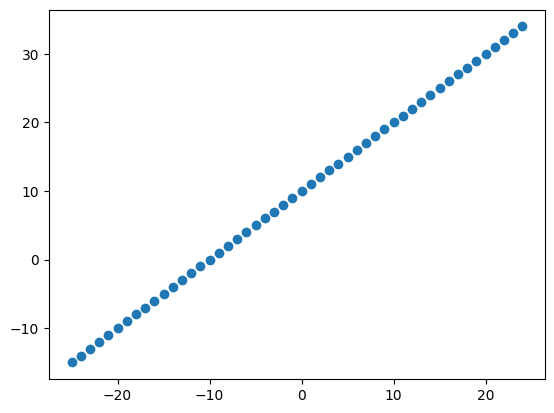

In [98]:
import matplotlib.pyplot as plt

plt.scatter(x, y)


In [109]:

# # => spliting
# from sklearn.model_selection import train_test_split

# x_train, x_test, y_train, y_test = train_test_split(x.numpy(), y.numpy(), test_size=0.2, random_state=42)

# len(x_train)
# x_train
# len(x_train), len(x_test), len(y_train), len(y_test)


In [108]:
 ## for aligned - manual
len(x)

x_train = x[:40]
x_test = x[40:]

y_train = y[:40]
y_test = y[40:]
len(x_train), len(x_test), len(y_train), len(y_test)

(40, 10, 40, 10)

# visualizing the data


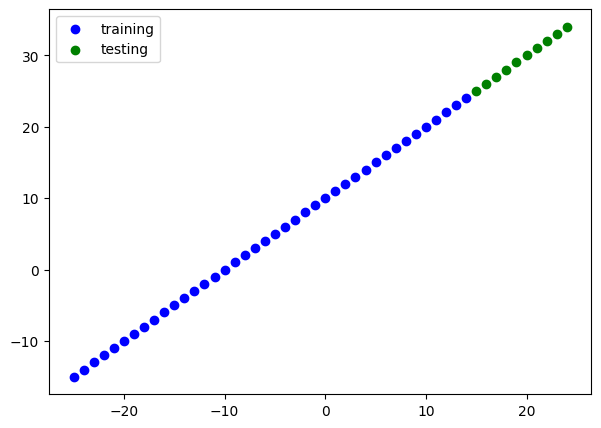

In [111]:
plt.figure(figsize=(7, 5))
# training
plt.scatter(x_train, y_train, c="b", label="training")
#test
plt.scatter(x_test, y_test, c="g", label="testing")

plt.legend()

## Creating neural network

In [117]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1) # Changed to 1 unit to match the label shape
])#cre
model.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["mae"]
)#compiling
x_reshaped = tf.expand_dims(x_train, axis=-1)
model.fit(x_reshaped, y_train, epochs=100) # fitting

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 9.8869 - mae: 9.8869
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 9.8000 - mae: 9.8000
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 9.7133 - mae: 9.7133
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 9.6266 - mae: 9.6266
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 9.5401 - mae: 9.5401
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 9.4537 - mae: 9.4537
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 9.3673 - mae: 9.3673
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 9.2811 - mae: 9.2811
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 9.1951 - mae: 9.1951
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 9.1091 - mae: 9.1091
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 9.0233 - mae: 9.0233
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 8.9375 - mae: 8.9375
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/ste

In [118]:
model.summary()

Model: "sequential_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_97 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_98 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95 (384.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64 (260.00 B)